In [1]:
import networkx as nx

In [2]:

G = nx.Graph()

In [3]:
G.add_node(1)
G.add_nodes_from([2,3,4])
G.add_edge(1,2)
G.add_edges_from([(2,3),(3,4)])

In [4]:
import matplotlib.pyplot as plt

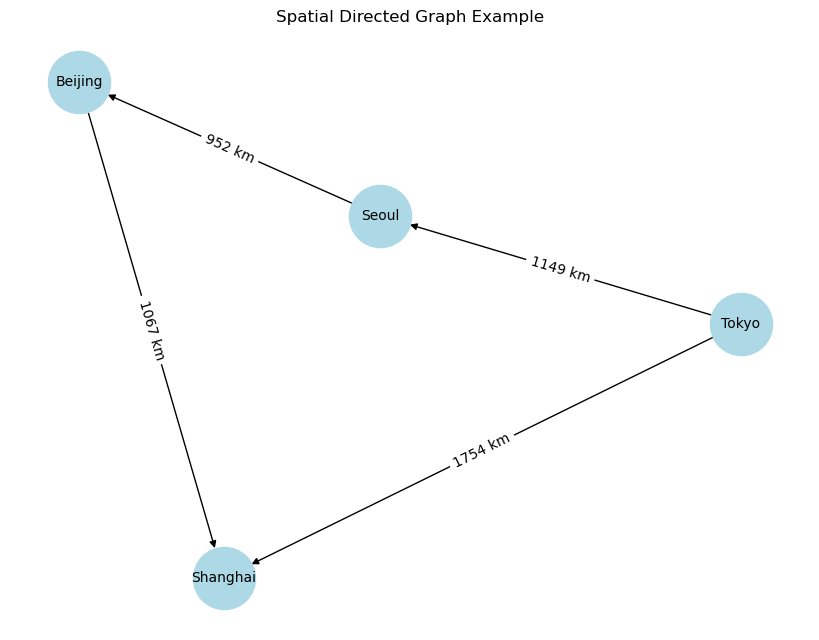

In [6]:
from math import radians, sin, cos, sqrt, atan2

# -----------------------
# 1 定义城市及经纬度
# -----------------------

cities = {
    "Tokyo": (35.6762, 139.6503),
    "Seoul": (37.5665, 126.9780),
    "Beijing": (39.9042, 116.4074),
    "Shanghai": (31.2304, 121.4737)
}

# -----------------------
# 2 创建有向图
# -----------------------

G = nx.DiGraph()

# 添加节点
for city, (lat, lon) in cities.items():
    G.add_node(city, lat=lat, lon=lon)

# -----------------------
# 3 定义航线关系
# -----------------------

routes = [
("Tokyo","Seoul"),
("Tokyo","Shanghai"),
("Seoul","Beijing"),
("Beijing","Shanghai")
]

# -----------------------
# 4 计算地理距离
# -----------------------

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    dlat = radians(lat2-lat1)
    dlon = radians(lon2-lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2*atan2(sqrt(a), sqrt(1-a))

    return R*c

# 添加边并计算距离
for source, target in routes:

    lat1, lon1 = cities[source]
    lat2, lon2 = cities[target]

    dist = haversine(lat1, lon1, lat2, lon2)

    G.add_edge(source, target, distance=dist)

# -----------------------
# 5 构建空间位置
# -----------------------

pos = {
node: (data["lon"], data["lat"])
for node, data in G.nodes(data=True)
}

# -----------------------
# 6 可视化
# -----------------------

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    font_size=10,
    arrows=True
)

# 显示距离标签
edge_labels = {
(u,v): f"{d['distance']:.0f} km"
for u,v,d in G.edges(data=True)
}

nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels)

plt.title("Spatial Directed Graph Example")
plt.show()